<a href="https://www.kaggle.com/code/lalit7881/global-ai-index-2026-cambridge-harvard-eda-100?scriptVersionId=316690119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/ai-readiness-and-growth-150-countries/w1_v2_CODEBOOK_MASTER_AI_DATA.pdf
/kaggle/input/datasets/patelris/ai-readiness-and-growth-150-countries/GAID_MASTER_V2_COMPILATION_FINAL.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/patelris/ai-readiness-and-growth-150-countries/GAID_MASTER_V2_COMPILATION_FINAL.csv")

In [3]:
df.head()

,Year,Country,ISO3,Metric,Value,Dataset,Source,Source_Category,Source_File,Source_Type,Source_Year
0,1998,Algeria,DZA,Field Weighted Citation Impact: All,0.665692,Stanford AI Index - Research and Development,Stanford AI Index,Research and Development,1. Research and Development-2021_Publications_...,xlsx,2021
1,1998,Algeria,DZA,Field Weighted Citation Impact: Institutional,0.911613,Stanford AI Index - Research and Development,Stanford AI Index,Research and Development,1. Research and Development-2021_Publications_...,xlsx,2021
2,1998,Algeria,DZA,Field Weighted Citation Impact: International,0.722979,Stanford AI Index - Research and Development,Stanford AI Index,Research and Development,1. Research and Development-2021_Publications_...,xlsx,2021
3,1998,Algeria,DZA,Field Weighted Citation Impact: National,0.618755,Stanford AI Index - Research and Development,Stanford AI Index,Research and Development,1. Research and Development-2021_Publications_...,xlsx,2021
4,1998,Algeria,DZA,Field Weighted Citation Impact: Single_Author,0.394339,Stanford AI Index - Research and Development,Stanford AI Index,Research and Development,1. Research and Development-2021_Publications_...,xlsx,2021


In [4]:
df.tail()

,Year,Country,ISO3,Metric,Value,Dataset,Source,Source_Category,Source_File,Source_Type,Source_Year
259541,2025,Zimbabwe,ZWE,WB GovTech: Core Government Systems Index (CGSI),0.513430,World Bank GovTech Maturity Index (GTMI),World Bank - GovTech Maturity Index,Governance/Digital Infrastructure,wbg_govtech_panel_aggregator.py,csv,2026
259542,2025,Zimbabwe,ZWE,WB GovTech: Digital Citizen Engagement Index (...,0.184782,World Bank GovTech Maturity Index (GTMI),World Bank - GovTech Maturity Index,Governance/Digital Infrastructure,wbg_govtech_panel_aggregator.py,csv,2026
259543,2025,Zimbabwe,ZWE,WB GovTech: Government Technology Enablers Ind...,0.348998,World Bank GovTech Maturity Index (GTMI),World Bank - GovTech Maturity Index,Governance/Digital Infrastructure,wbg_govtech_panel_aggregator.py,csv,2026
259544,2025,Zimbabwe,ZWE,WB GovTech: Overall Maturity Index (GTMI),0.452456,World Bank GovTech Maturity Index (GTMI),World Bank - GovTech Maturity Index,Governance/Digital Infrastructure,wbg_govtech_panel_aggregator.py,csv,2026
259545,2025,Zimbabwe,ZWE,WB GovTech: Public Service Delivery Index (PSDI),0.762615,World Bank GovTech Maturity Index (GTMI),World Bank - GovTech Maturity Index,Governance/Digital Infrastructure,wbg_govtech_panel_aggregator.py,csv,2026


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259546 entries, 0 to 259545
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Year             259546 non-null  int64  
 1   Country          259546 non-null  object 
 2   ISO3             259546 non-null  object 
 3   Metric           259546 non-null  object 
 4   Value            259398 non-null  float64
 5   Dataset          259546 non-null  object 
 6   Source           259546 non-null  object 
 7   Source_Category  259546 non-null  object 
 8   Source_File      259546 non-null  object 
 9   Source_Type      259546 non-null  object 
 10  Source_Year      259546 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 21.8+ MB


In [6]:
df.describe()

,Year,Value,Source_Year
count,259546.000000,2.593980e+05,259546.000000
mean,2016.710321,8.654563e+21,2023.483826
std,4.830747,2.968738e+24,1.251644
min,1998.000000,-4.300000e+01,2021.000000
25%,2014.000000,4.000000e+00,2024.000000
50%,2017.000000,1.783820e+01,2024.000000
75%,2020.000000,5.001183e+01,2024.000000
max,2025.000000,1.476066e+27,2026.000000


In [7]:
df.isnull().sum()

Year                 0
Country              0
ISO3                 0
Metric               0
Value              148
Dataset              0
Source               0
Source_Category      0
Source_File          0
Source_Type          0
Source_Year          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Year', 'Country', 'ISO3', 'Metric', 'Value', 'Dataset', 'Source',
       'Source_Category', 'Source_File', 'Source_Type', 'Source_Year'],
      dtype='object')

In [10]:
df.dtypes

Year                 int64
Country             object
ISO3                object
Metric              object
Value              float64
Dataset             object
Source              object
Source_Category     object
Source_File         object
Source_Type         object
Source_Year          int64
dtype: object

In [11]:
df.shape

(259546, 11)

In [12]:
df.nunique()

Year                   28
Country               227
ISO3                  227
Metric              24453
Value              182181
Dataset                26
Source                 11
Source_Category        21
Source_File           161
Source_Type             2
Source_Year             6
dtype: int64

## EDA

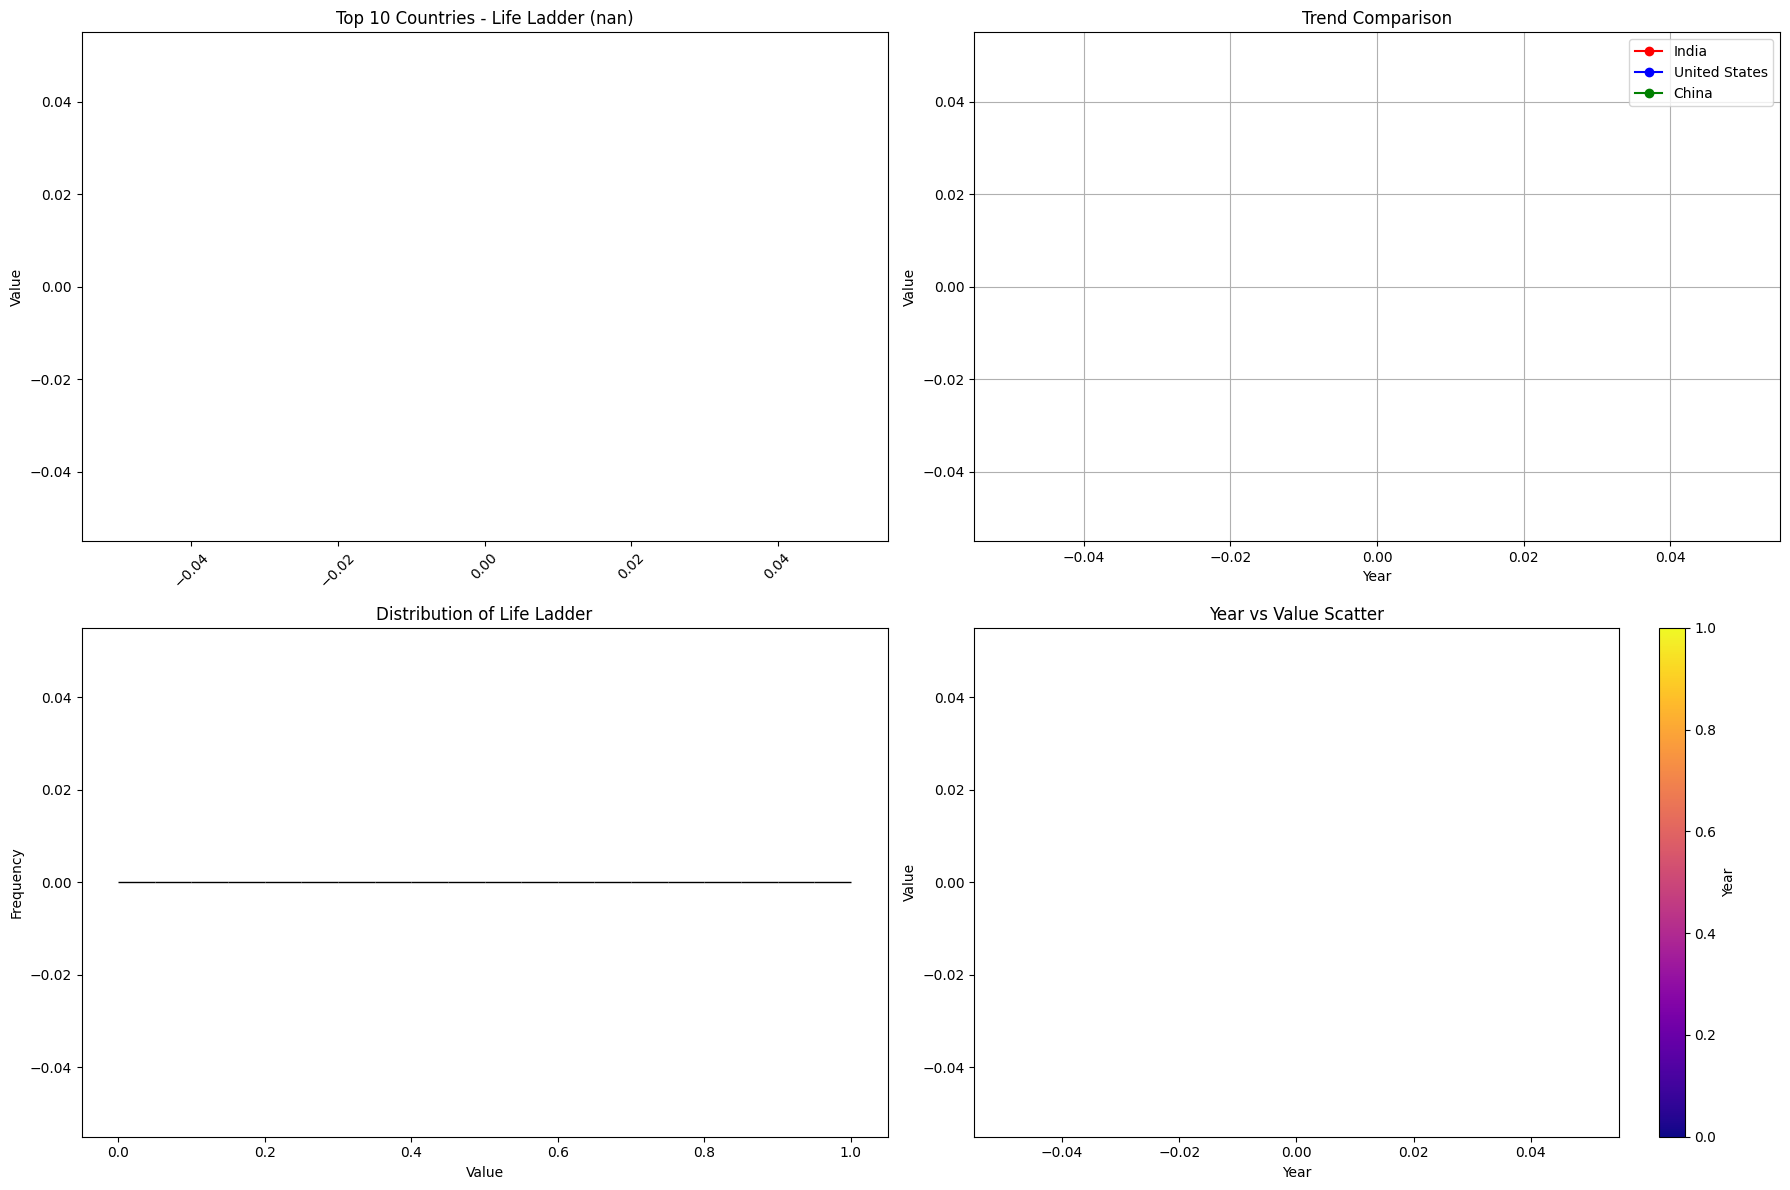

In [13]:
# ================================
# 1. BASIC CLEANING
# ================================
df = df.dropna(subset=['Value'])  # remove missing values

# ================================
# 2. SELECT METRIC
# ================================
metric_name = 'Life Ladder'   # change if needed

df_metric = df[df['Metric'] == metric_name]

# ================================
# 3. TOP COUNTRIES (LATEST YEAR)
# ================================
latest_year = df_metric['Year'].max()
df_latest = df_metric[df_metric['Year'] == latest_year]

top10 = df_latest.sort_values(by='Value', ascending=False).head(10)

# ================================
# 4. PLOT SETUP
# ================================
plt.figure(figsize=(18,12))

# ================================
# 5. BAR CHART (TOP COUNTRIES)
# ================================
plt.subplot(2,2,1)
colors_bar = plt.cm.viridis(np.linspace(0,1,len(top10)))

plt.bar(top10['Country'], top10['Value'], color=colors_bar)
plt.title(f"Top 10 Countries - {metric_name} ({latest_year})")
plt.xticks(rotation=45)
plt.ylabel("Value")

# ================================
# 6. LINE CHART (MULTI-COUNTRY TREND)
# ================================
plt.subplot(2,2,2)
countries = ['India', 'United States', 'China']

colors_line = ['red', 'blue', 'green']

for i, country in enumerate(countries):
    temp = df_metric[df_metric['Country'] == country]
    plt.plot(temp['Year'], temp['Value'],
             marker='o',
             color=colors_line[i],
             label=country)

plt.title("Trend Comparison")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

# ================================
# 7. HISTOGRAM (DISTRIBUTION)
# ================================
plt.subplot(2,2,3)

plt.hist(df_metric['Value'], bins=20, color='orange', edgecolor='black')
plt.title(f"Distribution of {metric_name}")
plt.xlabel("Value")
plt.ylabel("Frequency")

# ================================
# 8. SCATTER PLOT (YEAR vs VALUE)
# ================================
plt.subplot(2,2,4)

colors_scatter = df_metric['Year']

plt.scatter(df_metric['Year'], df_metric['Value'],
            c=colors_scatter,
            cmap='plasma')

plt.colorbar(label='Year')
plt.title("Year vs Value Scatter")
plt.xlabel("Year")
plt.ylabel("Value")

# ================================
# 9. FINAL LAYOUT
# ================================
plt.tight_layout()
plt.show()

Before cleaning: (3917, 24434)
After column cleaning: (3917, 8)
Target Metric: Field Weighted Citation Impact: All
Final dataset shape: (3917, 7)
Logistic Regression Accuracy: 0.9656
Random Forest Accuracy: 1.0000


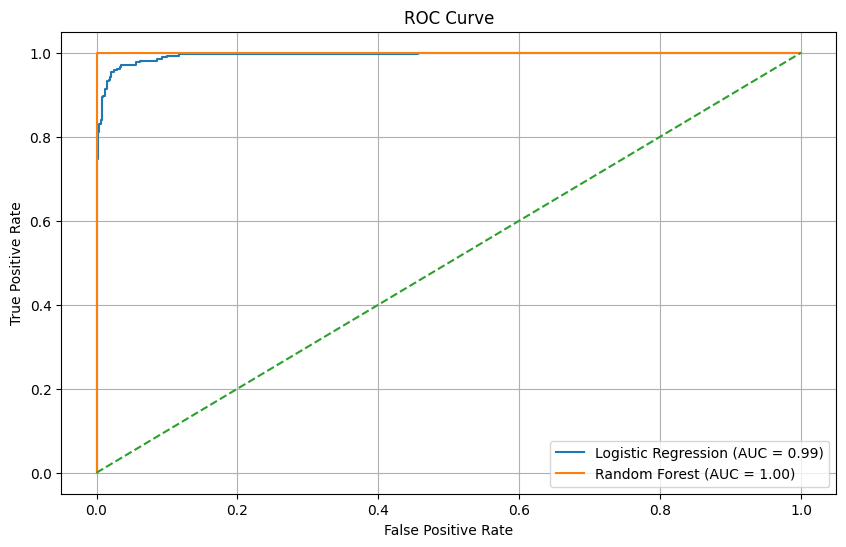

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ================================
# 1. PIVOT (LONG → WIDE)
# ================================
df_wide = df.pivot_table(
    index=['Country', 'Year'],
    columns='Metric',
    values='Value'
).reset_index()

print("Before cleaning:", df_wide.shape)

# ================================
# 2. DROP COLUMNS WITH TOO MANY NaNs
# ================================
threshold = int(0.5 * len(df_wide))  # keep columns with at least 50% data
df_wide = df_wide.dropna(axis=1, thresh=threshold)

print("After column cleaning:", df_wide.shape)

# ================================
# 3. FILL REMAINING NaNs (IMPORTANT)
# ================================
df_wide = df_wide.fillna(df_wide.median(numeric_only=True))

# ================================
# 4. SELECT TARGET COLUMN
# ================================
# Choose first numeric column automatically (safe)
numeric_cols = df_wide.select_dtypes(include=np.number).columns.tolist()

# Remove Year if present
numeric_cols = [col for col in numeric_cols if col != 'Year']

target_metric = numeric_cols[0]
print("Target Metric:", target_metric)

# ================================
# 5. CREATE TARGET (Binary)
# ================================
threshold = df_wide[target_metric].median()
df_wide['Target'] = (df_wide[target_metric] > threshold).astype(int)

# ================================
# 6. FEATURES & LABEL
# ================================
X = df_wide.drop(columns=['Target', 'Country'])
y = df_wide['Target']

print("Final dataset shape:", X.shape)

# ================================
# 7. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 8. SCALING (NO LEAKAGE)
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 9. MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ================================
# 10. TRAIN + EVALUATE
# ================================
plt.figure(figsize=(10,6))

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ================================
# 11. ROC CURVE
# ================================
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!